In [1]:
"""
DeepHalo + Sparse shocks simulation suite.
"""

import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
tf.keras.backend.set_floatx("float64")


from dataclasses import dataclass
from choice_learn.data import ChoiceDataset

import pandas as pd
import os
import sys

project_root = os.path.abspath(os.getcwd())
sys.path.insert(0, project_root)


import types
import tqdm.auto as _tqdm_auto

# Bypass tqdm in LuSparseRandomLogit to avoid printing a new line for every iteration
_fake_tqdm = types.ModuleType("tqdm")
_fake_tqdm.tqdm   = _tqdm_auto.tqdm
_fake_tqdm.trange = _tqdm_auto.trange
sys.modules["tqdm"] = _fake_tqdm


from BayesianSparseDeepHalo.DeepHalo import DeepHaloEncoder

from BayesianSparseDeepHalo.DeepHalo_MCEM_Core import (
    compute_probs_and_ll_batch_masked,
    build_choice_dataset_from_market_counts,
    calibrate_mcmc_stepsizes,
    SparseDeepHaloMCEM,
)


# restore the tqdm
from tqdm.auto import tqdm, trange

In [2]:
# ============================================================
# Dataclasses 
# ============================================================
@dataclass
class SimParams:
    """Simulation Parameters for Data Generation"""
    T: int = 100
    M: int = 15
    J: int = 12
    Nt: int = 1000
    D: int = 2
    pi: float = 0.9
    sigma_xibar: float = 0.5
    sigma_eta: float = 0.5
    seed: int = 123


@dataclass
class MCMCParams:
    """Hyperparameters for the MCMC sampler used inside MCEM"""
    R0: int = 200
    G: int = 2000
    burn: int = 500
    # Priors
    tau0: float = 1e-3
    tau1: float = 1.0
    a_phi: float = 1.0
    b_phi: float = 1.0
    V_beta: float = 10.0
    V_xibar: float = 10.0
    V_r: float = 0.5
    kappa_beta: float = 2.38 
    step_beta: float = 0.05
    step_r: float = 0.10
    step_xibar: float = 0.20
    step_eta: float = 0.30
    # Random-coefficient mask (all dims random by default, set in run_one_rep)
    random_coef_mask: object = None


@dataclass
class CalibParams:
    """Parameters for the MCMC Calibration Phase"""
    calib_iters: int = 500
    burn_in: int = 200
    adapt_every: int = 25
    accept_target_low: float = 0.30
    accept_target_high: float = 0.50
    upscale_ratio: float = 1.10
    downscale_ratio: float = 0.90
    min_step: float = 1e-4
    max_step: float = 5.0


@dataclass
class EMParams:
    """Hyperparameters controlling the outer MCEM loop"""
    outer_iters: int = 25
    recalibrate_each_outer: bool = False
    mcmc_per_outer: int = 2000
    burn: int = 1000
    thin: int = 1
    nn_steps: int = 150
    nn_lr: float = 1e-3
    nn_l2: float = 1e-6



In [3]:
# ============================================================
# Baseline helpers  (unchanged from DeepHalo_sparse_Lu.py)
# ============================================================
def fit_baseline(X_train, q_train, avail_train, encoder_kwargs,
                 R0=200, steps=400, lr=1e-3, nn_l2=1e-6, seed=0):
    tf.random.set_seed(seed)
    X     = tf.constant(X_train,    tf.float64)
    q     = tf.constant(q_train,    tf.float64)
    avail = tf.constant(avail_train, tf.float64)
    T, M, D = X_train.shape

    enc  = DeepHaloEncoder(**{**encoder_kwargs, "out_dim": D})
    enc(X[:2], avail[:2], training=False)  # build weights

    beta    = tf.Variable(tf.zeros((D,), tf.float64))
    r       = tf.Variable(tf.zeros((D,), tf.float64))
    v_draws = tf.random.normal((R0, D), dtype=tf.float64)
    opt     = tf.keras.optimizers.Adam(lr)

    @tf.function
    def step():
        with tf.GradientTape() as tape:
            Z   = enc(X, avail, training=True)
            xi0 = tf.zeros((T, M), tf.float64)
            _, _, ll_vec = compute_probs_and_ll_batch_masked(Z, q, avail, xi0, beta, r, v_draws)
            nll  = -tf.reduce_sum(ll_vec) / (tf.reduce_sum(q) + 1e-12)
            l2   = tf.add_n([tf.reduce_sum(w**2) for w in enc.trainable_weights])
            loss = nll + tf.cast(nn_l2, tf.float64) * l2
        grads = tape.gradient(loss, enc.trainable_weights + [beta, r])
        opt.apply_gradients(zip(grads, enc.trainable_weights + [beta, r]))
        return loss

    for _ in tqdm(range(steps), desc="Fit baseline DeepHalo", leave=False):
        step()
    return {"encoder": enc, "beta": beta.numpy(), "r": r.numpy()}


def fit_xibar_only(X_train, q_train, avail_train, encoder_kwargs,
                   R0=200, steps=600, lr=1e-3, nn_l2=1e-6, xi_l2=1e-3, seed=0):
    tf.random.set_seed(seed)
    X     = tf.constant(X_train,    tf.float64)
    q     = tf.constant(q_train,    tf.float64)
    avail = tf.constant(avail_train, tf.float64)
    T, M, D = X_train.shape

    
    enc    = DeepHaloEncoder(**{**encoder_kwargs, "out_dim": D})
    enc(X[:2], avail[:2], training=False)

    beta    = tf.Variable(tf.zeros((D,), tf.float64))
    r       = tf.Variable(tf.zeros((D,), tf.float64))
    xi_bar  = tf.Variable(tf.zeros((T,), tf.float64))
    v_draws = tf.random.normal((R0, D), dtype=tf.float64)
    opt     = tf.keras.optimizers.Adam(lr)

    @tf.function
    def step():
        with tf.GradientTape() as tape:
            Z  = enc(X, avail, training=True)
            xi = xi_bar[:, None] + tf.zeros((T, M), tf.float64)
            _, _, ll_vec = compute_probs_and_ll_batch_masked(Z, q, avail, xi, beta, r, v_draws)
            nll   = -tf.reduce_sum(ll_vec) / (tf.reduce_sum(q) + 1e-12)
            l2net = tf.add_n([tf.reduce_sum(w**2) for w in enc.trainable_weights])
            l2xi  = tf.reduce_sum(xi_bar**2)
            loss  = (nll
                     + tf.cast(nn_l2, tf.float64) * l2net
                     + tf.cast(xi_l2, tf.float64) * l2xi)
        grads = tape.gradient(loss, enc.trainable_weights + [beta, r, xi_bar])
        opt.apply_gradients(zip(grads, enc.trainable_weights + [beta, r, xi_bar]))
        return loss

    for _ in tqdm(range(steps), desc="Fit DeepHalo xibar-only", leave=False):
        step()
    return {"encoder": enc, "beta": beta.numpy(), "r": r.numpy(), "xi_bar": xi_bar.numpy()}


# ============================================================
# Prediction helpers
# ============================================================
def compute_prediction_nll(encoder, X_np, q_np, avail_np,
                            beta, r, xi_bar, eta,
                            R0=200, seed=0):
    tf.random.set_seed(seed)
    X     = tf.constant(X_np,    tf.float64)
    q     = tf.constant(q_np,    tf.float64)
    avail = tf.constant(avail_np, tf.float64)
    Z     = encoder(X, avail, training=False)
    Dz    = int(Z.shape[-1])

    v_draws = tf.random.normal((R0, Dz), dtype=tf.float64)
    xi      = tf.constant(xi_bar, tf.float64)[:, None] + tf.constant(eta, tf.float64)

    _, _, ll_vec = compute_probs_and_ll_batch_masked(
        Z, q, avail, xi,
        tf.constant(beta, tf.float64),
        tf.constant(r,    tf.float64),
        v_draws,
    )
    N_total = tf.reduce_sum(q)
    return float((-tf.reduce_sum(ll_vec) / (N_total + 1e-12)).numpy())


def infer_xi_bar_for_markets(encoder, X_np, q_np, avail_np,
                             beta, r, R0=200, iters=200, lr=0.1, seed=0):
    tf.random.set_seed(seed)
    X     = tf.constant(X_np,    tf.float64)
    q     = tf.constant(q_np,    tf.float64)
    avail = tf.constant(avail_np, tf.float64)
    Z     = encoder(X, avail, training=False)
    Dz    = int(Z.shape[-1])
    Tt    = X_np.shape[0]
    M     = X_np.shape[1]

    v_draws = tf.random.normal((R0, Dz), dtype=tf.float64)
    beta_tf = tf.constant(beta, tf.float64)
    r_tf    = tf.constant(r,    tf.float64)
    xi_bar  = tf.Variable(tf.zeros((Tt,), tf.float64))
    opt     = tf.keras.optimizers.Adam(lr)

    @tf.function
    def step():
        with tf.GradientTape() as tape:
            xi = xi_bar[:, None] + tf.zeros((Tt, M), tf.float64)
            _, _, ll_vec = compute_probs_and_ll_batch_masked(Z, q, avail, xi, beta_tf, r_tf, v_draws)
            nll = -tf.reduce_sum(ll_vec) / (tf.reduce_sum(q) + 1e-12)
        grads = tape.gradient(nll, [xi_bar])
        opt.apply_gradients(zip(grads, [xi_bar]))
        return nll

    for _ in range(iters):
        step()
    return xi_bar.numpy()



In [4]:
# ============================================================
# Teacher / DGP
# ============================================================
def generate_teacher_dgp(sim: SimParams, encoder_kwargs=None,
                         beta_star=None, r_star=None):
    rng = np.random.default_rng(sim.seed)
    tf.random.set_seed(sim.seed)
    T, M, J, Nt, D = sim.T, sim.M, sim.J, sim.Nt, sim.D

    if encoder_kwargs is None:
        encoder_kwargs = dict(H=7, depth=3, embed=16, dropout=0.0, block_type="qua", out_dim=D)
    else:
        encoder_kwargs = {**encoder_kwargs, "out_dim": D}

    X_univ = rng.normal(size=(M, D)).astype(np.float64)
    avail  = np.zeros((T, M), dtype=np.float64)
    for t in range(T):
        idx = rng.choice(M, size=J, replace=False)
        avail[t, idx] = 1.0

    X_full = np.tile(X_univ[None, :, :], (T, 1, 1))
    X_full *= avail[:, :, None]

    beta_star = rng.normal(size=(D,)).astype(np.float64) if beta_star is None \
                else np.array(beta_star, dtype=np.float64).reshape(-1)
    r_star    = rng.normal(loc=-0.2, scale=0.3, size=(D,)).astype(np.float64) if r_star is None \
                else np.array(r_star, dtype=np.float64).reshape(-1)

    teacher = DeepHaloEncoder(**encoder_kwargs)
    teacher(tf.constant(X_full[:2], tf.float64), tf.constant(avail[:2], tf.float64), training=False)
    Z = teacher(tf.constant(X_full, tf.float64), tf.constant(avail, tf.float64), training=False)
    Z = Z.numpy()                                                   # (T, M, D)

    xi_bar_star = rng.normal(0.0, sim.sigma_xibar, size=(T,)).astype(np.float64)
    eta_star    = np.zeros((T, M), dtype=np.float64)
    non_zero    = (rng.uniform(size=(T, M)) < (1 - sim.pi)) & (avail > 0.5)
    eta_star[non_zero] = rng.normal(0.0, sim.sigma_eta,
                                    size=int(np.sum(non_zero))).astype(np.float64)
    xi_star = xi_bar_star[:, None] + eta_star

    R0_sim  = 500
    v_draws = tf.random.normal((R0_sim, D), dtype=tf.float64)
    q_dummy = tf.zeros((T, M + 1), dtype=tf.float64)
    sigma_t, _, _ = compute_probs_and_ll_batch_masked(
        tf.constant(Z, tf.float64), q_dummy,
        tf.constant(avail, tf.float64),
        tf.constant(xi_star, tf.float64),
        tf.constant(beta_star, tf.float64),
        tf.constant(r_star,    tf.float64),
        v_draws,
    )
    shares = sigma_t.numpy()                                        # (T, M+1)
    q      = np.round(Nt * shares).astype(np.int32)
    q[:, 0] += Nt - q.sum(axis=1)

    teacher.trainable = False
    data = {"X": X_full, "q": q, "Nt": Nt, "avail": avail}
    true = {"X_univ": X_univ, "X_full": X_full, "avail": avail,
            "Z_teacher": Z,
            "beta_star": beta_star, "r_star": r_star,
            "xi_bar_star": xi_bar_star, "eta_star": eta_star, "xi_star": xi_star}
    return data, true, teacher



In [5]:
# ============================================================
# Evaluation helpers
# ============================================================
def sparsity_recovery(eta_hat, eta_star, avail, tau=0.05):
    mask   = avail > 0.5
    nz_true = (np.abs(eta_star) > 1e-12) & mask
    nz_hat  = (np.abs(eta_hat)  > tau)   & mask
    tp  = int(np.sum(nz_true  &  nz_hat))
    fp  = int(np.sum(~nz_true &  nz_hat))
    fn  = int(np.sum(nz_true  & ~nz_hat))
    prec = tp / (tp + fp + 1e-12)
    rec  = tp / (tp + fn + 1e-12)
    f1   = 2 * prec * rec / (prec + rec + 1e-12)
    return {"tp": tp, "fp": fp, "fn": fn,
            "precision": float(prec), "recall": float(rec), "f1": float(f1)}


def theta_distance_zip(enc_a, enc_b, X_build, A_build):
    enc_a(tf.constant(X_build, tf.float64), tf.constant(A_build, tf.float64), training=False)
    enc_b(tf.constant(X_build, tf.float64), tf.constant(A_build, tf.float64), training=False)
    wa, wb = enc_a.weights, enc_b.weights
    L = min(len(wa), len(wb))
    s = 0.0
    for a, b in zip(wa[:L], wb[:L]):
        da, db = a.numpy().ravel(), b.numpy().ravel()
        if da.shape != db.shape:
            continue
        s += np.sum((da - db) ** 2)
    return float(np.sqrt(s))


In [6]:
# ============================================================
# Train/test split
# ============================================================
def split_train_test_markets(T, test_frac=0.25, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(T)
    rng.shuffle(idx)
    n_test    = int(np.round(T * test_frac))
    test_idx  = np.sort(idx[:n_test])
    train_idx = np.sort(idx[n_test:])
    return train_idx, test_idx


# ============================================================
# run_one_rep  –  single simulation replicate
# ============================================================
def run_one_rep(sim: SimParams, test_frac=0.25, encoder_kwargs=None, tau_eval=0.05):
    data, true, teacher = generate_teacher_dgp(sim, encoder_kwargs=encoder_kwargs)

    X, q, avail = data["X"], data["q"], data["avail"]
    T, M, D     = X.shape

    train_idx, test_idx = split_train_test_markets(T, test_frac=test_frac, seed=sim.seed + 999)
    X_tr,  q_tr,  A_tr  = X[train_idx],  q[train_idx],  avail[train_idx]
    X_te,  q_te,  A_te  = X[test_idx],   q[test_idx],   avail[test_idx]

    if encoder_kwargs is None:
        encoder_kwargs = dict(H=7, depth=3, embed=16, dropout=0.0, block_type="qua", out_dim=D)

    # Baseline DeepHalo 
    est1 = fit_baseline(X_tr, q_tr, A_tr, encoder_kwargs,
                        R0=200, steps=600, lr=1e-3, nn_l2=1e-6, seed=sim.seed + 1)
    nll1_strict = compute_prediction_nll(
        est1["encoder"], X_te, q_te, A_te, est1["beta"], est1["r"],
        xi_bar=np.zeros(len(test_idx)), eta=np.zeros((len(test_idx), M)),
        R0=200, seed=sim.seed + 10)
    nll1_adapt  = compute_prediction_nll(
        est1["encoder"], X_te, q_te, A_te, est1["beta"], est1["r"],
        xi_bar=infer_xi_bar_for_markets(
            est1["encoder"], X_te, q_te, A_te, est1["beta"], est1["r"],
            R0=200, iters=200, lr=0.1, seed=sim.seed + 20),
        eta=np.zeros((len(test_idx), M)),
        R0=200, seed=sim.seed + 21)

    # DeepHalo + xi_bar
    est2 = fit_xibar_only(X_tr, q_tr, A_tr, encoder_kwargs,
                          R0=200, steps=600, lr=1e-3, nn_l2=1e-6,
                          xi_l2=1e-3, seed=sim.seed + 2)
    nll2_strict = compute_prediction_nll(
        est2["encoder"], X_te, q_te, A_te, est2["beta"], est2["r"],
        xi_bar=np.zeros(len(test_idx)), eta=np.zeros((len(test_idx), M)),
        R0=200, seed=sim.seed + 11)
    
    nll2_adapt  = compute_prediction_nll(
        est2["encoder"], X_te, q_te, A_te, est2["beta"], est2["r"],
        xi_bar=infer_xi_bar_for_markets(
            est2["encoder"], X_te, q_te, A_te, est2["beta"], est2["r"],
            R0=200, iters=200, lr=0.1, seed=sim.seed + 30),
        eta=np.zeros((len(test_idx), M)),
        R0=200, seed=sim.seed + 31)

    # Sparse DeepHalo MCEM  (uses Lu module) 
    enc3 = DeepHaloEncoder(**{**encoder_kwargs, "out_dim": D})
    
    enc3(tf.constant(X_tr[:2], tf.float64),
         tf.constant(A_tr[:2], tf.float64), training=False)

    # random_coef_mask: all D dims are random 
    random_coef_mask = np.ones(D, dtype=np.float64)

    mcmc   = MCMCParams(R0=200, tau0=1e-3, tau1=float(sim.sigma_eta),
                        kappa_beta=0.05, step_eta=0.30,
                        random_coef_mask=random_coef_mask)
    # sim_params for Lu model: T=T_train, J=M (inside alts), D=Dz
    sim_lu = SimParams(T=len(train_idx), M=M, J=M, Nt=sim.Nt, D=D,
                       pi=sim.pi, sigma_xibar=sim.sigma_xibar,
                       sigma_eta=sim.sigma_eta, seed=sim.seed)
    
    calib  = CalibParams(calib_iters=500, burn_in=200, adapt_every=25)
    em     = EMParams(outer_iters=25, recalibrate_each_outer=False,
                      mcmc_per_outer=2000, burn=1000, thin=1,
                      nn_steps=100, nn_lr=1e-3, nn_l2=1e-6)

    exp3  = SparseDeepHaloMCEM(
        X_tr, q_tr, A_tr, enc3,
        sim_params=sim_lu, mcmc_params=mcmc,
        calib_params=calib, em_params=em,
        seed=2026 + sim.seed,
    )
    out3  = exp3.run()

    beta3,  r3    = out3["beta_last"],    out3["r_last"]
    xi_bar3, eta3 = out3["xi_bar_last"],  out3["eta_last"]

    nll3_strict = compute_prediction_nll(
        enc3, X_te, q_te, A_te, beta3, r3,
        xi_bar=np.zeros(len(test_idx)), eta=np.zeros((len(test_idx), M)),
        R0=200, seed=sim.seed + 12)
    nll3_adapt  = compute_prediction_nll(
        enc3, X_te, q_te, A_te, beta3, r3,
        xi_bar=infer_xi_bar_for_markets(
            enc3, X_te, q_te, A_te, beta3, r3,
            R0=200, iters=200, lr=0.1, seed=sim.seed + 40),
        eta=np.zeros((len(test_idx), M)),
        R0=200, seed=sim.seed + 41)

    rec = sparsity_recovery(eta3, true["eta_star"][train_idx], A_tr, tau=tau_eval)

    # distances to teacher 
    X_tr2, A_tr2 = X_tr[:2], A_tr[:2]
    theta_d1 = theta_distance_zip(est1["encoder"], teacher, X_tr2, A_tr2)
    theta_d2 = theta_distance_zip(est2["encoder"], teacher, X_tr2, A_tr2)
    theta_d3 = theta_distance_zip(enc3,            teacher, X_tr2, A_tr2)

    beta_d1 = float(np.linalg.norm(est1["beta"] - true["beta_star"]))
    beta_d2 = float(np.linalg.norm(est2["beta"] - true["beta_star"]))
    beta_d3 = float(np.linalg.norm(beta3        - true["beta_star"]))
    r_d1    = float(np.linalg.norm(est1["r"]    - true["r_star"]))
    r_d2    = float(np.linalg.norm(est2["r"]    - true["r_star"]))
    r_d3    = float(np.linalg.norm(r3           - true["r_star"]))

    return {
        "seed": int(sim.seed), "T": int(sim.T), "M": int(sim.M),
        "J": int(sim.J), "D": int(sim.D), "Nt": int(sim.Nt),
        "pi": float(sim.pi),
        "sigma_xibar": float(sim.sigma_xibar), "sigma_eta": float(sim.sigma_eta),
        "nll_strict_baseline": float(nll1_strict),
        "nll_strict_xibaronly":    float(nll2_strict),
        "nll_strict_sparse":   float(nll3_strict),
        "nll_adapt_baseline":  float(nll1_adapt),
        "nll_adapt_xibaronly":     float(nll2_adapt),
        "nll_adapt_sparse":    float(nll3_adapt),
        "eta_f1":       float(rec["f1"]),
        "eta_precision":float(rec["precision"]),
        "eta_recall":   float(rec["recall"]),
        "beta_dist_baseline": beta_d1, "r_dist_baseline": r_d1, "theta_dist_baseline": theta_d1,
        "beta_dist_xibar":    beta_d2, "r_dist_xibar":    r_d2, "theta_dist_xibar":    theta_d2,
        "beta_dist_sparse":   beta_d3, "r_dist_sparse":   r_d3, "theta_dist_sparse":   theta_d3,
        "step_beta":       out3["step_beta"],
        "step_r":          out3["step_r"],
        "step_xibar":      out3["step_xibar"],
        "step_eta":        out3["step_eta"],
    }



In [7]:
# ============================================================
# run_grid
# ============================================================
def run_grid(pis=(0.8, 0.9, 0.95), reps=5, base_seed=123,
             T=25, M=15, J=12, Nt=1000, D=2,
             sigma_xibar=0.5, sigma_eta=0.5,
             test_frac=0.25, encoder_kwargs=None, tau_eval=0.05):
    rows = []
    for pi in tqdm(pis, desc="pi grid"):
        for r in tqdm(range(reps), desc="rep", leave=False):
            sim = SimParams(
                T=int(T), M=int(M), J=int(J), Nt=int(Nt), D=int(D),
                pi=float(pi),
                sigma_xibar=float(sigma_xibar), sigma_eta=float(sigma_eta),
                seed=int(base_seed + 10000 * int(round(100 * pi)) + r),
            )
            row = run_one_rep(sim, test_frac=test_frac,
                              encoder_kwargs=encoder_kwargs, tau_eval=tau_eval)
            rows.append(row)
            print(
                f"pi={pi:.2f}  strict NLL (b,xi,s)="
                f"{row['nll_strict_baseline']:.3f},{row['nll_strict_xibaronly']:.3f},{row['nll_strict_sparse']:.3f}  "
                f"eta_F1={row['eta_f1']:.3f}"
            )
    return pd.DataFrame(rows)

    
df = run_grid(
    pis=(0.8, 0.9, 0.95), reps=5, base_seed=123,
    T=25, M=15, J=12, Nt=1000, D=2,
    sigma_xibar=0.5, sigma_eta=0.5, test_frac=0.25,
    encoder_kwargs=dict(H=7, depth=3, embed=16, dropout=0.0,
                        block_type="qua", out_dim=2),
    tau_eval=0.05,
)

out_dir = os.path.join(project_root, "Experiments", "Joint Lu Zhang results" )
os.makedirs(out_dir, exist_ok=True)

out_csv = os.path.join(out_dir, "Bayesian_sparse_deephalo_results.csv")
df.to_csv(out_csv, index=False)
print(f"Saved {out_csv} with cols {list(df.columns)}")
print(df.groupby("pi")[["nll_strict_sparse", "nll_adapt_sparse", "eta_f1"]].mean())


pi grid:   0%|          | 0/3 [00:00<?, ?it/s]

rep:   0%|          | 0/5 [00:00<?, ?it/s]

Fit baseline DeepHalo:   0%|          | 0/600 [00:00<?, ?it/s]

Fit DeepHalo + xibar-only:   0%|          | 0/600 [00:00<?, ?it/s]

Sparse DeepHalo MCEM outer:   0%|          | 0/25 [00:00<?, ?it/s]

...

pi=0.95 rep=3 strict NLL (b,xi,s): 1.056, 1.118, 1.056 | adapt NLL (b,xi,s): 1.054, 1.059, 1.053 | etaF1=0.231


Fit baseline DeepHalo:   0%|          | 0/600 [00:00<?, ?it/s]

Fit DeepHalo + xibar-only:   0%|          | 0/600 [00:00<?, ?it/s]

Sparse DeepHalo MCEM outer:   0%|          | 0/25 [00:00<?, ?it/s]

pi=0.95 rep=4 strict NLL (b,xi,s): 2.398, 2.404, 2.469 | adapt NLL (b,xi,s): 2.391, 2.390, 2.385 | etaF1=0.286
Saved: simulation_masked_outside_rewritten.csv with cols=['seed', 'T', 'M', 'J', 'D', 'Nt', 'pi', 'sigma_xibar', 'sigma_eta', 'nll_strict_baseline', 'nll_strict_xibaronly', 'nll_strict_sparse', 'nll_adapt_baseline', 'nll_adapt_xibaronly', 'nll_adapt_sparse', 'eta_f1', 'eta_precision', 'eta_recall', 'beta_dist_baseline', 'r_dist_baseline', 'theta_dist_baseline', 'beta_dist_xibar', 'r_dist_xibar', 'theta_dist_xibar', 'beta_dist_sparse', 'r_dist_sparse', 'theta_dist_sparse', 'step_beta', 'step_r', 'step_xibar', 'step_eta']
      nll_strict_sparse  nll_adapt_sparse    eta_f1
pi                                                 
0.80           2.469448          2.135853  0.178750
0.90           2.086171          2.054753  0.217902
0.95           2.230388          1.960473  0.278009


In [8]:
df

,seed,T,M,J,D,Nt,pi,sigma_xibar,sigma_eta,nll_strict_baseline,...,beta_dist_xibar,r_dist_xibar,theta_dist_xibar,beta_dist_sparse,r_dist_sparse,theta_dist_sparse,step_beta,step_r,step_xibar,step_eta
0,800123,25,15,12,2,1000,0.80,0.5,0.5,2.518508,...,0.916510,0.536495,30.850805,1.825487,1.936510,30.122230,0.017260,0.130451,0.627686,0.778123
1,800124,25,15,12,2,1000,0.80,0.5,0.5,2.424242,...,0.873995,0.273698,30.720816,2.644195,3.817929,31.678736,0.017260,0.313843,0.266200,0.643077
2,800125,25,15,12,2,1000,0.80,0.5,0.5,2.488010,...,1.455242,0.251652,30.770560,2.557773,2.785502,30.666750,0.017260,0.313843,0.627686,0.707384
3,800126,25,15,12,2,1000,0.80,0.5,0.5,1.169597,...,1.884553,0.549239,30.092760,3.897990,1.007201,30.038366,0.017260,0.047351,0.220000,0.941529
4,800127,25,15,12,2,1000,0.80,0.5,0.5,2.222893,...,1.291406,0.393881,30.271987,0.709791,1.782090,30.346570,0.019177,0.034519,0.627686,0.778123
5,900123,25,15,12,2,1000,0.90,0.5,0.5,1.194872,...,2.248875,0.454107,29.975236,1.310487,0.473579,30.268923,0.066550,0.034519,0.627686,0.941529
6,900124,25,15,12,2,1000,0.90,0.5,0.5,2.227527,...,2.348122,0.357944,30.598273,6.883247,1.850309,30.954461,0.017260,0.057874,0.627686,0.707384
7,900125,25,15,12,2,1000,0.90,0.5,0.5,2.345877,...,0.964936,0.893176,31.100353,1.223064,0.756731,30.036010,0.017260,0.313843,0.220000,0.941529
8,900126,25,15,12,2,1000,0.90,0.5,0.5,2.284171,...,0.655089,0.522551,30.843195,3.934312,1.668504,30.377833,0.017260,0.313843,0.627686,0.855935
9,900127,25,15,12,2,1000,0.90,0.5,0.5,2.365596,...,1.206084,0.036758,30.458084,4.918259,1.642860,29.540808,0.017260,0.079388,0.627686,0.778123


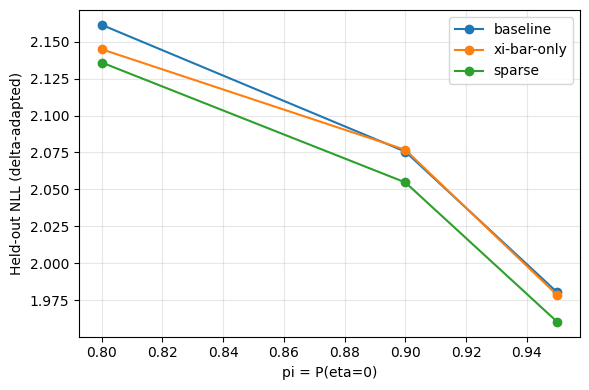

In [10]:
import matplotlib.pyplot as plt

# optional plot: adapted NLL vs pi
g = df.groupby("pi")[["nll_adapt_baseline", "nll_adapt_xibaronly", "nll_adapt_sparse"]].mean().reset_index()
plt.figure(figsize=(6, 4))
plt.plot(g["pi"], g["nll_adapt_baseline"], marker="o", label="baseline")
plt.plot(g["pi"], g["nll_adapt_xibaronly"], marker="o", label="xi-bar-only")
plt.plot(g["pi"], g["nll_adapt_sparse"], marker="o", label="sparse")
plt.xlabel("pi = P(eta=0)")
plt.ylabel("Held-out NLL (delta-adapted)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
    cols = ["nll_strict_baseline", "nll_strict_xibaronly", "nll_strict_sparse",
            "nll_adapt_baseline", "nll_adapt_xibaronly", "nll_adapt_sparse",
            "eta_f1", "beta_dist_baseline", "theta_dist_baseline", "beta_dist_xibar", "theta_dist_xibar", "beta_dist_sparse", "theta_dist_sparse"]
    print("\nMeans by pi:")
    print(df.groupby("pi")[cols].mean())


Means by pi:
      nll_strict_baseline  nll_strict_xibaronly  nll_strict_sparse  \
pi                                                                   
0.80             2.164650              2.152285           2.469448   
0.90             2.083609              2.094022           2.086171   
0.95             1.999078              2.005939           2.230388   

      nll_adapt_baseline  nll_adapt_xibaronly  nll_adapt_sparse    eta_f1  \
pi                                                                          
0.80            2.161314             2.144810          2.135853  0.178750   
0.90            2.075577             2.076800          2.054753  0.217902   
0.95            1.980423             1.978567          1.960473  0.278009   

      beta_dist_baseline  theta_dist_baseline  beta_dist_xibar  \
pi                                                               
0.80            1.202997            30.644813         1.284341   
0.90            1.551215            30.370767      